# SHS generation + analysis

In [11]:
# Sequence & structure 
RNA_SEQ =   "AAACAGAUCACCCGCUGAGCGGGUUAUCUGUU"
STRUCTURE = "()()()()()()()()()()()()()()()()"                   # overrides the predictor if set
STRUCTURE_PREDICTOR = "rnafold"          # rnafold, spotrna, rnaformer

# MSA size / reproducibility 
N = 1000
SEED = 42
PDB_ID = "None"

# Mutation parameters
WOBBLE_PROB            = 0.0  # 0.1
STEM_KEEP_PROB         = 0.0 # 0.99

# Base-triple / multiplet co-mutation (0.0 disables)
TRIPLET_PROB           = 0.0 # 0.0
TRIPLET_KEEP_PROB      = 0.99 # 0.99

# insertions / deletions
INSERTION_PROB_LOOP    = 0.0 # 0.2
DELETION_PROB_LOOP     = 0.0 # 0.8
LONG_INSERTION_PROB    = 0.00 # 0.05
LONG_DELETION_PROB     = 0.00 # 0.05
MAX_INSERTION_FRACTION = 0.0 # 0.1
MAX_DELETION_FRACTION  = 0.0 # 0.1

# Output
OUTPUT_JSON_DIR = "custom_msa_json_output"

# not used in the script 
INSERTION_PROB_STEM    = 0.0
DELETION_PROB_STEM     = 0.0

## Setup

In [12]:
import importlib
import os
import sys
from argparse import Namespace
from pathlib import Path

%matplotlib inline

_candidates = [Path.cwd(), Path.cwd() / "SHS-Generator"]
SHS_DIR = next((p for p in _candidates if (p / "shs_generator.py").exists()), None)
if SHS_DIR is None:
    raise FileNotFoundError("Could not find shs_generator.py.")
SHS_DIR = SHS_DIR.resolve()
os.chdir(SHS_DIR)
if str(SHS_DIR) not in sys.path:
    sys.path.insert(0, str(SHS_DIR))

import shs_generator
import shs_analyzer
importlib.reload(shs_generator)
importlib.reload(shs_analyzer)

print("SHS-Generator dir:", SHS_DIR)

SHS-Generator dir: /home/kaii/bachelor_project/SyntheticEvolution/SHS-Generator


## Generate the SHS

In [13]:

STRUCTURE = "".join(["\"" + c + "\"" if c.isdigit() else c for c in STRUCTURE])

args = Namespace(
    structure_predictor    = None if STRUCTURE else STRUCTURE_PREDICTOR,
    structure              = STRUCTURE,
    rna_seq                = RNA_SEQ,
    protein_seq            = "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQ",  # placeholder; AF3 JSON needs a protein chain
    input_json_path        = None,
    pdb_id                 = PDB_ID,
    output_json_dir        = OUTPUT_JSON_DIR,
    N                      = N,
    insertion_prob_loop    = INSERTION_PROB_LOOP,
    deletion_prob_loop     = DELETION_PROB_LOOP,
    insertion_prob_stem    = INSERTION_PROB_STEM,
    deletion_prob_stem     = DELETION_PROB_STEM,
    wobble_prob            = WOBBLE_PROB,
    long_insertion_prob    = LONG_INSERTION_PROB,
    long_deletion_prob     = LONG_DELETION_PROB,
    max_insertion_fraction = MAX_INSERTION_FRACTION,
    max_deletion_fraction  = MAX_DELETION_FRACTION,
    stem_keep_prob         = STEM_KEEP_PROB,
    triplet_prob           = TRIPLET_PROB,
    triplet_keep_prob      = TRIPLET_KEEP_PROB,
    seed                   = SEED,
    max_chains             = None,
    plot                   = False,
    print_msa              = False,
    show_plot              = False,
)

generator = shs_generator.MsaGenerator(args)
generator.process()
output_name    = generator.build_output_name()
generated_json = Path(args.output_json_dir) / f"{output_name}.json"
assert generated_json.exists(), f"Expected output not found: {generated_json}"

2026-07-23 15:03:33,615 - INFO - Processing RNA sequence: AAACAGAUCACCCGCUGAGCGGGUUAUCUGUU
2026-07-23 15:03:33,617 - INFO - Using provided dot-bracket structure: ()()()()()()()()()()()()()()()()
2026-07-23 15:03:33,618 - INFO - Predicted pairs: {1: 0, 0: 1, 3: 2, 2: 3, 5: 4, 4: 5, 7: 6, 6: 7, 9: 8, 8: 9, 11: 10, 10: 11, 13: 12, 12: 13, 15: 14, 14: 15, 17: 16, 16: 17, 19: 18, 18: 19, 21: 20, 20: 21, 23: 22, 22: 23, 25: 24, 24: 25, 27: 26, 26: 27, 29: 28, 28: 29, 31: 30, 30: 31}
2026-07-23 15:03:33,618 - INFO - Secondary structure has 16 unique base pairs.
2026-07-23 15:03:33,648 - INFO - ✅ JSON written to: custom_msa_json_output/None_custom_rnamsa_N1000_seed42_insl_0.0_dell_0.0_inss_0.0_dels_0.0_lins_0.0_ldels_0.0_maxinslen_0_maxdellen_0_wobble_0.0_stemkeep_0.0_None.json


## Analyze & render

Query length: 32  |  MSA rows: 1000  |  covariation matrix: (32, 32)


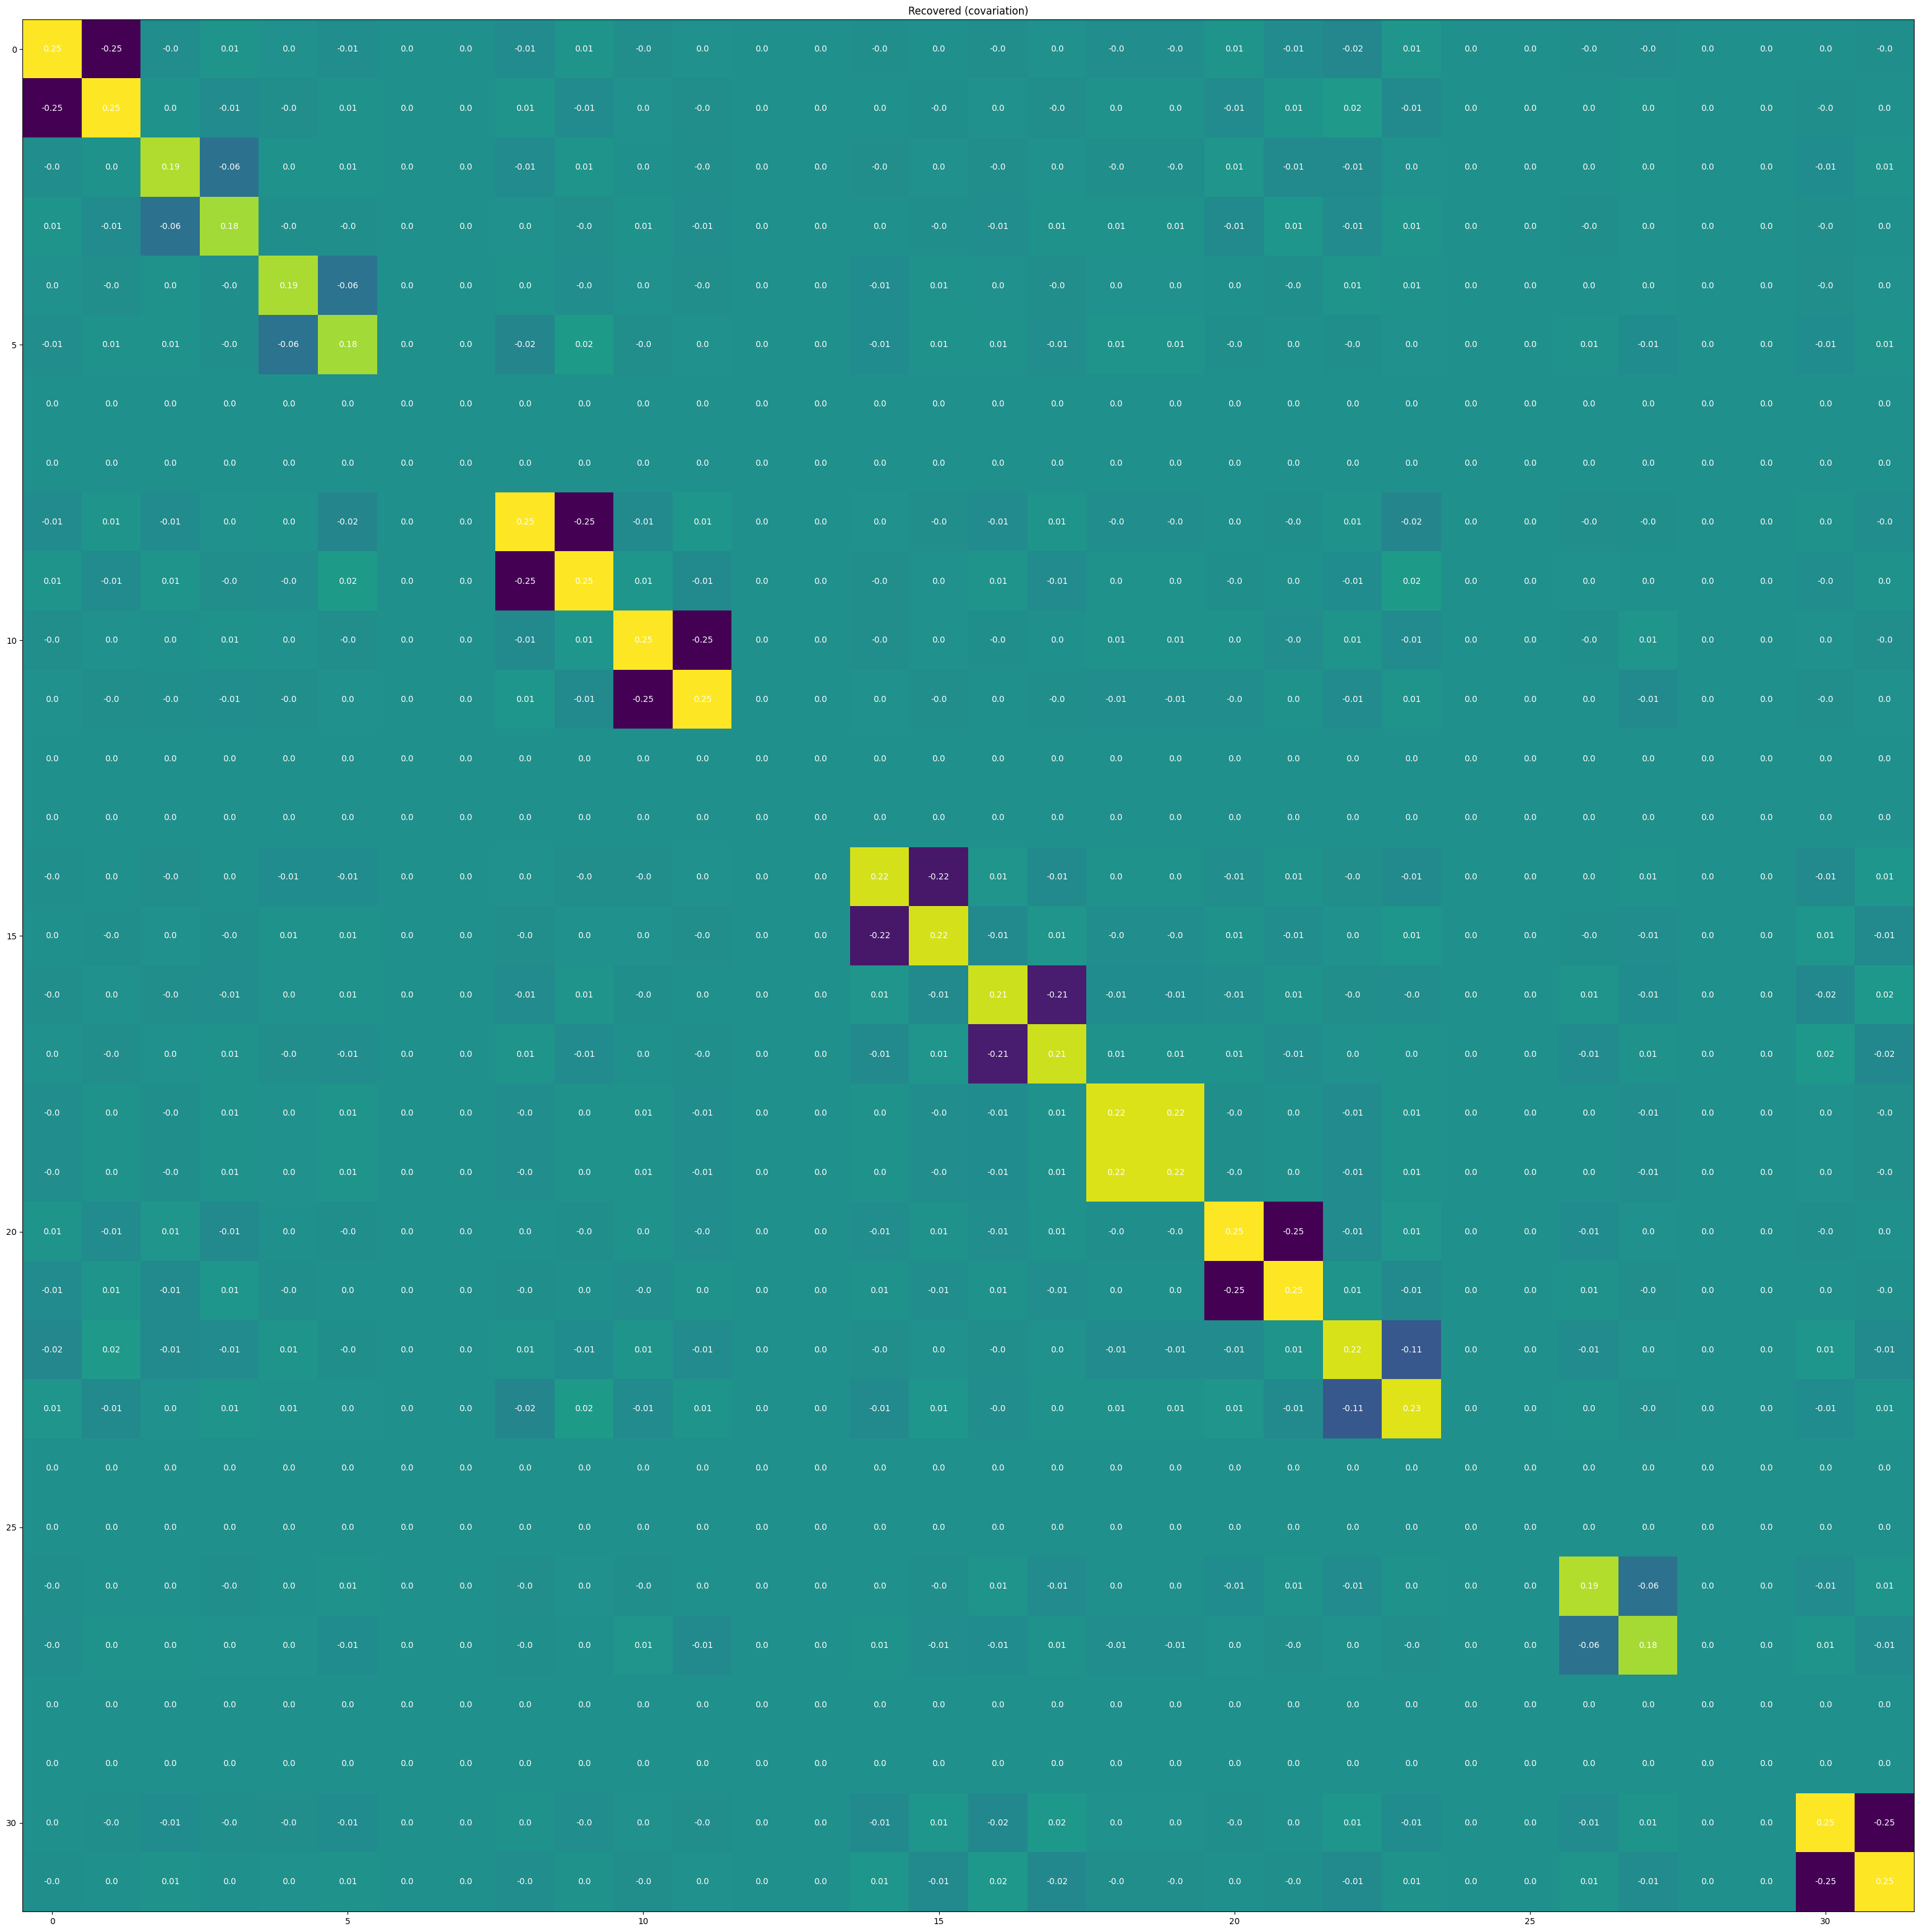

AAACAGAUCACCCGCUGAGCGGGUUAUCUGUU
AUUAAUUAUAGCGCAUGCCGGCAUCGAUGCUA
UAGCAUUAUACGAUCGGUGCCGUGCGUAGCAU
AUCGAUGCCGGCGCCGGCGCUGAUAUAUGCAU
UAUAGCUAUACGGCAUGUGCUGAUCGAUGCAU
UACGCGUAUACGGCGUGCCGUGGCCGUAGCAU
AUAUGCGCCGCGGCAUUAAUGUUGCGUAGUAU
UAAUGCUACGCGGCCGUAAUCGUGAUUAAUUA
AUAUCGGCUAGCAUCGUAAUGCUGAUGCGUAU
UAAUGCGCCGGCAUCGGCCGCGUGAUUAAUUA
AUCGAUUACGCGAUCGGCAUGUAUAUGCGUUA


In [14]:
USE_CORRCOEF = False
seq, msa, matrix = shs_analyzer.compute_cov(str(generated_json), use_corrcoef=USE_CORRCOEF)
metric_name = "Corrcoef" if USE_CORRCOEF else "Covariation"
print(f"Query length: {len(seq)}  |  MSA rows: {len(msa) + 1}  |  {metric_name.lower()} matrix: {matrix.shape}")

pairs = generator.pairs
seq_len = len(seq)
# depends on PAIR_MUTATIONS and STEM_KEEP_PROB so not trivial
paired_variance = 0.2
paired_covariance = 0.4
# default is randomly selected, so 0 but also depends on the DELETION_PROB_LOOP and LONG_DELETION_PROB
unpaired_variance = 0.2
unpaired_covariance = 0

input_matrix = shs_analyzer.structure_matrix(pairs, seq_len, paired_covariance, unpaired_covariance, paired_variance, unpaired_variance)
vmin, vmax = min(input_matrix.min(), matrix.min()), max(input_matrix.max(), matrix.max())
# shs_analyzer.plot_matrix(input_matrix, "Input", vmin=vmin, vmax=vmax)
shs_analyzer.plot_matrix(matrix, show_values=True)

print(seq)
for i, s in enumerate(msa):
    if i >= 10: break
    print("".join(s))


# Clean up

In [15]:
if generated_json.exists():
    generated_json.unlink()
    try:
        generated_json.parent.rmdir()
    except OSError:
        pass
    print("Removed generated output:", generated_json)

Removed generated output: custom_msa_json_output/None_custom_rnamsa_N1000_seed42_insl_0.0_dell_0.0_inss_0.0_dels_0.0_lins_0.0_ldels_0.0_maxinslen_0_maxdellen_0_wobble_0.0_stemkeep_0.0_None.json
